# The off-peak penalty

Peak hours are when service quality matters most for commuters — but
they're also when MTA invests the most attention. Off-peak service is
where neglect, if it exists, would show up first.

This notebook compares peak and off-peak CJTP across lines, and asks
which lines lose the most when rush hour ends.

In [1]:
import sys
sys.path.append("../code")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils import MTA_COLORS, MAIN_LINES

RAW = Path("../data/raw")
FIGURES = Path("../output/figures")

df = pd.read_csv(RAW / "cjm_2015_present.csv", parse_dates=["month"])
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
df["year"] = df["month"].dt.year
df = df[df["line"].isin(MAIN_LINES) & (df["line"] != "S 42nd")]
df.shape

(4932, 13)

In [2]:
by_line_period = (
    df[df["year"] >= 2022]
    .groupby(["line", "period"])["customer_journey_time_performance"]
    .mean()
    .unstack("period")
    .reindex([l for l in MAIN_LINES if l != "S 42nd"])
)
by_line_period["penalty"] = by_line_period["peak"] - by_line_period["offpeak"]
by_line_period.round(3).sort_values("penalty", ascending=False)

period,offpeak,peak,penalty
line,,,
F,0.789,0.842,0.053
A,0.788,0.841,0.053
E,0.817,0.870,0.053
D,0.757,0.796,0.039
R,0.790,0.829,0.038
2,0.835,0.872,0.037
7,0.876,0.905,0.029
N,0.800,0.824,0.025
5,0.858,0.881,0.023


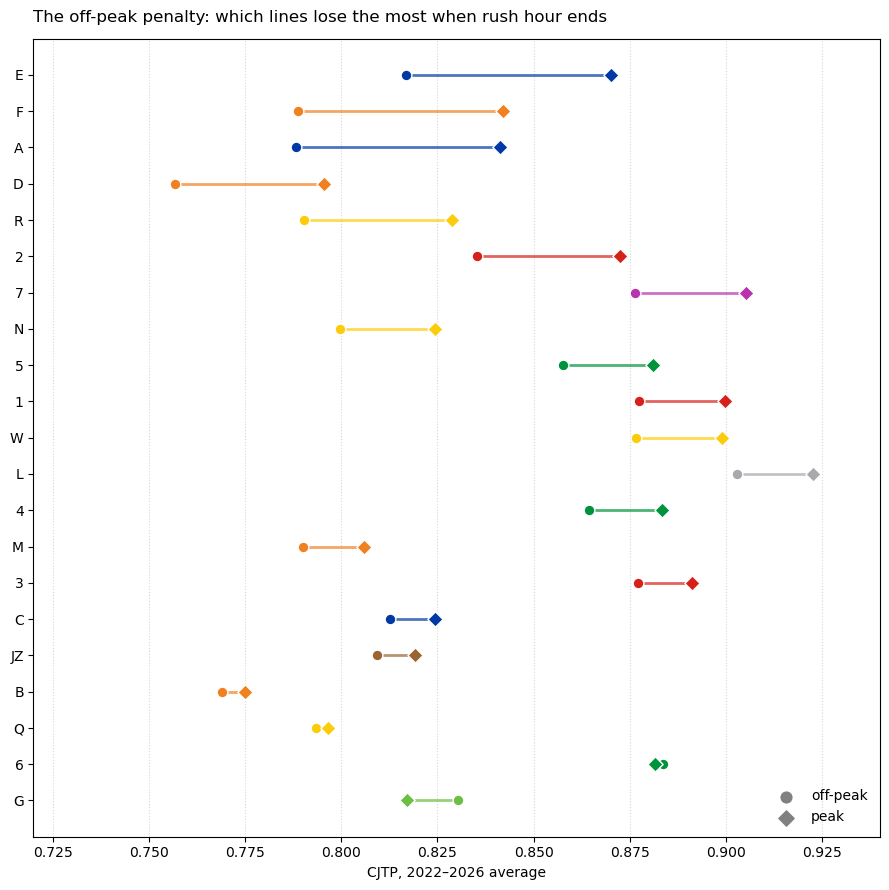

In [5]:
ranked = by_line_period.dropna().sort_values("penalty", ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))

for line in ranked.index:
    peak_val = ranked.loc[line, "peak"]
    off_val = ranked.loc[line, "offpeak"]
    color = MTA_COLORS.get(line, "gray")
    ax.plot([off_val, peak_val], [line, line], color=color, linewidth=2, alpha=0.7)
    ax.scatter(off_val, line, color=color, s=60, zorder=3, marker="o",
               edgecolor="white", linewidth=1)
    ax.scatter(peak_val, line, color=color, s=60, zorder=3, marker="D",
               edgecolor="white", linewidth=1)

ax.scatter([], [], color="gray", marker="o", s=60, label="off-peak")
ax.scatter([], [], color="gray", marker="D", s=60, label="peak")
ax.legend(loc="lower right", frameon=False)

ax.set_xlim(0.72, 0.94)
ax.set_xlabel("CJTP, 2022–2026 average")
ax.set_ylabel("")
ax.set_title("The off-peak penalty: which lines lose the most when rush hour ends",
             loc="left", pad=12)
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
fig.savefig(FIGURES / "03_offpeak_penalty_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "03_offpeak_penalty_wip.pdf", bbox_inches="tight")

## What this shows

Off-peak CJTP is lower than peak CJTP across nearly every line — the
opposite of what most riders would expect. The mechanism isn't that
trains run worse off-peak; it's that they run *less often*, and CJTP
penalizes the wait. When a rider misses an off-peak train, the next one
is fifteen minutes away, and that gap shows up in the metric.

The penalty is largest on F, A, and E — long lines that connect outer
boroughs to Manhattan. The smallest penalties (and only reversals) are
on 6 and G — short lines that don't depend on the Manhattan trunk for
their ridership.

This reframes off-peak service quality as a frequency problem, not a
reliability problem. It's a different lever, and a different kind of
investment.